In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("8f35d745-2ed9-4ca4-b7ea-f355e6fd00c5_Data.csv")

df.replace("..", np.nan, inplace=True)

id_cols = ["Country Name", "Series Name"]
year_cols = [col for col in df.columns if "YR" in col]

df = df[id_cols + year_cols]

df_long = df.melt(
    id_vars=["Country Name", "Series Name"],
    var_name="Year",
    value_name="Value"
)

df_long["Year"] = df_long["Year"].str.extract(r"(\d{4})")
df_long["Value"] = pd.to_numeric(df_long["Value"], errors="coerce")

df_clean = df_long.pivot_table(
    index=["Country Name", "Year"],
    columns="Series Name",
    values="Value"
).reset_index()

df_clean.columns.name = None

df_clean.rename(columns={
    "GDP per capita (current US$)": "GDP_per_Capita_USD",
    "Individuals using the Internet (% of population)": "Internet_Usage_%"
}, inplace=True)

df_clean.dropna(
    how="all",
    subset=["GDP_per_Capita_USD", "Internet_Usage_%"],
    inplace=True
)

gdp_wide = df_clean.pivot(
    index="Country Name",
    columns="Year",
    values="GDP_per_Capita_USD"
)

internet_wide = df_clean.pivot(
    index="Country Name",
    columns="Year",
    values="Internet_Usage_%"
)

gdp_wide.columns = [f"GDP_{col}" for col in gdp_wide.columns]
internet_wide.columns = [f"Internet_{col}" for col in internet_wide.columns]

df_wide = pd.concat([gdp_wide, internet_wide], axis=1).reset_index()

df_wide.to_csv("Cleaned_Wide_Format_Data.csv", index=False)

In [2]:
# Ensuring Year is numeric
df_clean["Year"] = df_clean["Year"].astype(int)

df_clean = df_clean.sort_values(["Country Name", "Year"])

df_clean["GDP_per_Capita_USD"] = (
    df_clean.groupby("Country Name")["GDP_per_Capita_USD"]
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

In [3]:
df_clean.to_csv("Cleaned_TimeSeries_Data.csv", index=False)

In [4]:
df_clean.head()

,Country Name,Year,GDP_per_Capita_USD,Internet_Usage_%
0,Afghanistan,2001,138.706822,0.004723
1,Afghanistan,2002,158.830455,0.004561
2,Afghanistan,2003,172.177342,0.087891
3,Afghanistan,2004,199.862953,0.105809
4,Afghanistan,2005,224.939673,1.224150


In [5]:
df_clean.shape

(6271, 4)

In [6]:
df_clean.head(10)

,Country Name,Year,GDP_per_Capita_USD,Internet_Usage_%
0,Afghanistan,2001,138.706822,0.004723
1,Afghanistan,2002,158.830455,0.004561
2,Afghanistan,2003,172.177342,0.087891
3,Afghanistan,2004,199.862953,0.105809
4,Afghanistan,2005,224.939673,1.224150
5,Afghanistan,2006,250.055486,2.107120
6,Afghanistan,2007,301.541985,1.900000
7,Afghanistan,2008,344.058315,1.840000
8,Afghanistan,2009,403.336699,3.550000
9,Afghanistan,2010,464.802816,4.000000


In [7]:
df_clean["Year"].dtype

dtype('int32')

In [8]:
(df_clean == "..").sum().sum()

0

In [9]:
df_clean[["GDP_per_Capita_USD","Internet_Usage_%"]].dtypes

GDP_per_Capita_USD    float64
Internet_Usage_%      float64
dtype: object

In [10]:
df_clean.duplicated(subset=["Country Name","Year"]).sum()

0

In [11]:
df = pd.read_csv("Cleaned_TimeSeries_Data.csv")

# view first rows
print(df.head())

# check structure
print(df.info())

# check missing values
print(df.isnull().sum())

  Country Name  Year  GDP_per_Capita_USD  Internet_Usage_%
0  Afghanistan  2001          138.706822          0.004723
1  Afghanistan  2002          158.830455          0.004561
2  Afghanistan  2003          172.177342          0.087891
3  Afghanistan  2004          199.862953          0.105809
4  Afghanistan  2005          224.939673          1.224150
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6271 entries, 0 to 6270
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country Name        6271 non-null   object 
 1   Year                6271 non-null   int64  
 2   GDP_per_Capita_USD  6222 non-null   float64
 3   Internet_Usage_%    5252 non-null   float64
dtypes: float64(2), int64(1), object(1)
memory usage: 196.1+ KB
None
Country Name             0
Year                     0
GDP_per_Capita_USD      49
Internet_Usage_%      1019
dtype: int64


In [12]:
# sort values for proper time alignment
df = df.sort_values(by=["Country Name", "Year"])

# reset index
df = df.reset_index(drop=True)

# verify alignment
print(df.head(10))

  Country Name  Year  GDP_per_Capita_USD  Internet_Usage_%
0  Afghanistan  2001          138.706822          0.004723
1  Afghanistan  2002          158.830455          0.004561
2  Afghanistan  2003          172.177342          0.087891
3  Afghanistan  2004          199.862953          0.105809
4  Afghanistan  2005          224.939673          1.224150
5  Afghanistan  2006          250.055486          2.107120
6  Afghanistan  2007          301.541985          1.900000
7  Afghanistan  2008          344.058315          1.840000
8  Afghanistan  2009          403.336699          3.550000
9  Afghanistan  2010          464.802816          4.000000


In [13]:
df['Year'] = pd.to_datetime(df['Year'], format='%Y')

# set index
df.set_index('Year', inplace=True)

print(df.head())

           Country Name  GDP_per_Capita_USD  Internet_Usage_%
Year                                                         
2001-01-01  Afghanistan          138.706822          0.004723
2002-01-01  Afghanistan          158.830455          0.004561
2003-01-01  Afghanistan          172.177342          0.087891
2004-01-01  Afghanistan          199.862953          0.105809
2005-01-01  Afghanistan          224.939673          1.224150


In [14]:
years_per_country = df.groupby("Country Name").size()
print(years_per_country)

Country Name
Afghanistan                    23
Africa Eastern and Southern    25
Africa Western and Central     25
Albania                        24
Algeria                        24
                               ..
West Bank and Gaza             24
World                          25
Yemen, Rep.                    19
Zambia                         24
Zimbabwe                       24
Length: 265, dtype: int64


In [15]:
print(df.describe())

       GDP_per_Capita_USD  Internet_Usage_%
count         6222.000000       5252.000000
mean         14639.535002         40.097830
std          23026.635803         31.333669
min            114.025509          0.000000
25%           1559.342288         10.000000
50%           5024.530642         34.700000
75%          18291.758012         69.000000
max         256951.074629        100.000000


In [16]:
correlation = df['Internet_Usage_%'].corr(df['GDP_per_Capita_USD'])
print("Correlation:", correlation)

Correlation: 0.6021818320865323


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

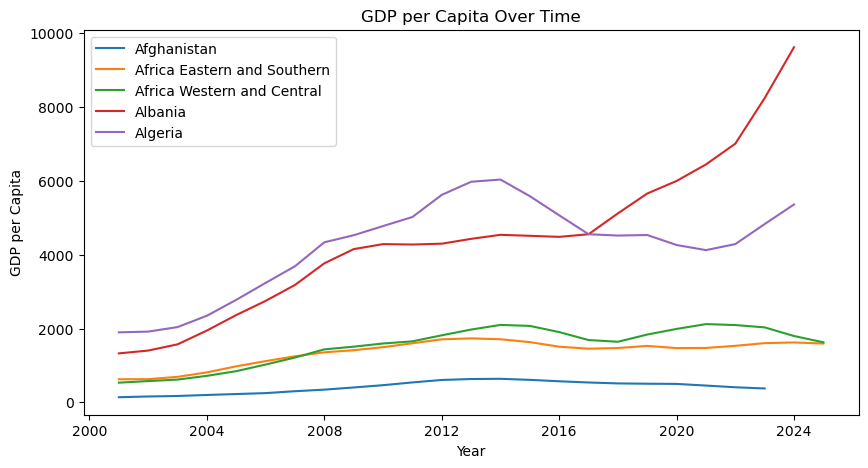

In [18]:
plt.figure(figsize=(10,5))

for country in df['Country Name'].unique()[:5]:  # first 5 countries
    country_data = df[df['Country Name'] == country]
    plt.plot(country_data.index,
             country_data['GDP_per_Capita_USD'],
             label=country)

plt.title("GDP per Capita Over Time")
plt.xlabel("Year")
plt.ylabel("GDP per Capita")
plt.legend()
plt.show()

In [19]:
df = df.reset_index()

<Axes: xlabel='Internet_Usage_%', ylabel='GDP_per_Capita_USD'>

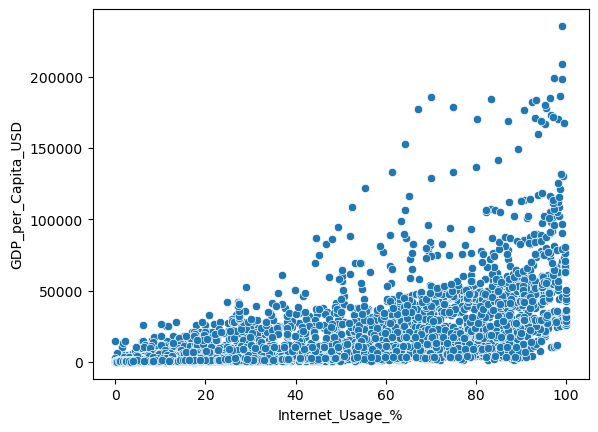

In [20]:
sns.scatterplot(data=df,
                x='Internet_Usage_%',
                y='GDP_per_Capita_USD')

In [21]:
print(df.duplicated(subset=['Country Name','Year']).sum())

0


In [22]:
df.to_csv("Cleaned_TimeSeries_Data_Final.csv", index=False)

In [23]:
df = pd.read_csv("Cleaned_TimeSeries_Data.csv")

# Time series alignment
df = df.sort_values(['Country Name', 'Year'])

# Remove duplicates
df = df.drop_duplicates(subset=['Country Name', 'Year'])

# Reset index
df = df.reset_index(drop=True)

# Optional: smoothing
df['GDP_Smoothed'] = df.groupby('Country Name')['GDP_per_Capita_USD'] \
                       .transform(lambda x: x.rolling(3).mean())

df['Internet_Smoothed'] = df.groupby('Country Name')['Internet_Usage_%'] \
                            .transform(lambda x: x.rolling(3).mean())

# Save final dataset
df.to_csv("Cleaned_TimeSeries_Data_Final.csv", index=False)

print("File saved successfully")

File saved successfully


In [24]:
import pandas as pd
import numpy as np

df = pd.read_csv("Cleaned_TimeSeries_Data_Final.csv")

# sort properly for time series
df = df.sort_values(['Country Name', 'Year'])
df = df.reset_index(drop=True)

In [25]:
df['GDP_per_Capita_USD'] = df.groupby('Country Name')['GDP_per_Capita_USD'] \
                             .transform(lambda x: x.interpolate())

df['Internet_Usage_%'] = df.groupby('Country Name')['Internet_Usage_%'] \
                           .transform(lambda x: x.interpolate())

In [26]:
df['GDP_lag_1'] = df.groupby('Country Name')['GDP_per_Capita_USD'].shift(1)

df['Internet_lag_1'] = df.groupby('Country Name')['Internet_Usage_%'].shift(1)

In [27]:
# Step 1: Interpolate missing values
df['GDP_per_Capita_USD'] = df.groupby('Country Name')['GDP_per_Capita_USD'] \
                             .transform(lambda x: x.interpolate())

df['Internet_Usage_%'] = df.groupby('Country Name')['Internet_Usage_%'] \
                           .transform(lambda x: x.interpolate())

# Step 2: Calculate growth rate safely
df['GDP_Growth_Rate'] = df.groupby('Country Name')['GDP_per_Capita_USD'] \
                          .pct_change(fill_method=None) * 100

df['Internet_Growth_Rate'] = df.groupby('Country Name')['Internet_Usage_%'] \
                               .pct_change(fill_method=None) * 100

In [28]:
df['GDP_MA_3'] = df.groupby('Country Name')['GDP_per_Capita_USD'] \
                   .transform(lambda x: x.rolling(3).mean())

df['Internet_MA_3'] = df.groupby('Country Name')['Internet_Usage_%'] \
                        .transform(lambda x: x.rolling(3).mean())

In [29]:
df = df.dropna()
df = df.reset_index(drop=True)

In [30]:
df.to_csv("Cleaned_TimeSeries_Data_Enhanced.csv", index=False)

LINEAR REGRESSION

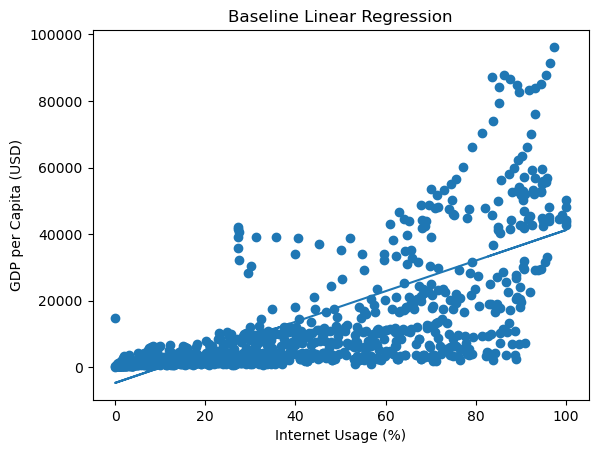

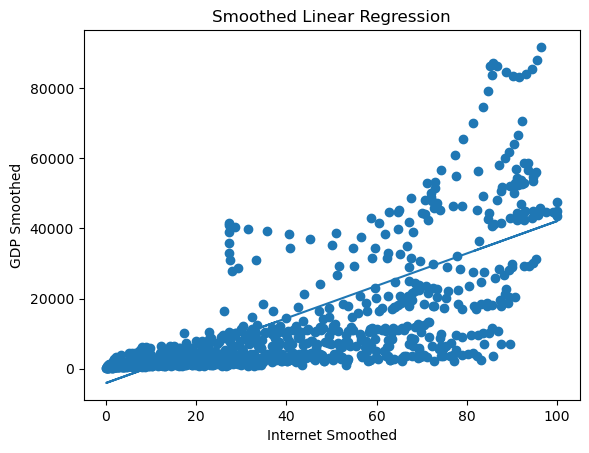

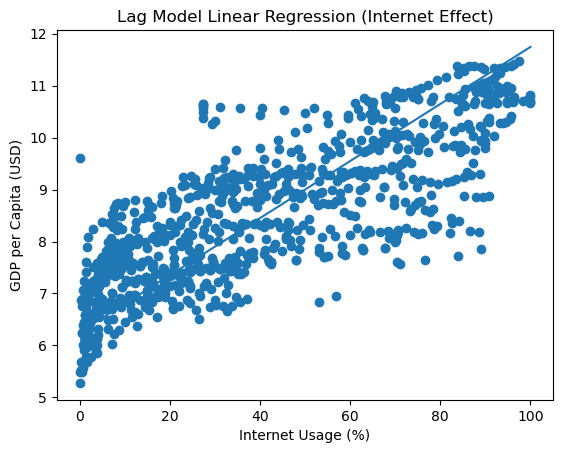

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv("Cleaned_TimeSeries_Data_Enhanced.csv")
df = df.dropna()

# MODEL 1: BASELINE

X1 = df[['Internet_Usage_%']]
y1 = df['GDP_per_Capita_USD']

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, shuffle=False
)

model1 = LinearRegression()
model1.fit(X1_train, y1_train)


plt.figure()
plt.scatter(X1_test, y1_test)
plt.plot(X1_test, model1.predict(X1_test))
plt.xlabel("Internet Usage (%)")
plt.ylabel("GDP per Capita (USD)")
plt.title("Baseline Linear Regression")
plt.show()



# MODEL 2: SMOOTHED

X2 = df[['Internet_Smoothed']]
y2 = df['GDP_Smoothed']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, shuffle=False
)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)


plt.figure()
plt.scatter(X2_test, y2_test)
plt.plot(X2_test, model2.predict(X2_test))
plt.xlabel("Internet Smoothed")
plt.ylabel("GDP Smoothed")
plt.title("Smoothed Linear Regression")
plt.show()



# MODEL 3: LAG MODEL

X3 = df[['Internet_Usage_%', 'GDP_lag_1', 'Internet_lag_1']]
y3 = np.log(df['GDP_per_Capita_USD'])

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, shuffle=False
)

model3 = LinearRegression()
model3.fit(X3_train, y3_train)

# For visualization: show effect of Internet_Usage_% only
internet_range = np.linspace(
    X3_test['Internet_Usage_%'].min(),
    X3_test['Internet_Usage_%'].max(),
    100
)

mean_gdp_lag = X3_test['GDP_lag_1'].mean()
mean_internet_lag = X3_test['Internet_lag_1'].mean()

X_plot = pd.DataFrame({
    'Internet_Usage_%': internet_range,
    'GDP_lag_1': mean_gdp_lag,
    'Internet_lag_1': mean_internet_lag
})

plt.figure()
plt.scatter(X3_test['Internet_Usage_%'], y3_test)
plt.plot(internet_range, model3.predict(X_plot))
plt.xlabel("Internet Usage (%)")
plt.ylabel("GDP per Capita (USD)")
plt.title("Lag Model Linear Regression (Internet Effect)")
plt.show()

LassoCV Regression

In [32]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

df = pd.read_csv("Cleaned_TimeSeries_Data_Enhanced.csv")

df['Internet_lag_1'] = df.groupby('Country Name')['Internet_Usage_%'].shift(1)
df['GDP_lag_1'] = df.groupby('Country Name')['GDP_per_Capita_USD'].shift(1)
df["Country_encoded"] = df["Country Name"].astype("category").cat.codes

df = df.dropna().reset_index(drop=True)

features = [
    'Internet_Usage_%', 'Year', 'Country_encoded', 
    'Internet_lag_1', 'GDP_lag_1', 'Internet_MA_3', 'GDP_MA_3'
]
X = df[features]
y = np.log(df['GDP_per_Capita_USD'])

X_train, X_test, y_train, y_test_lasso = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso_final = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_final.fit(X_train_scaled, y_train)

pred_lasso = lasso_final.predict(X_test_scaled)


Polynomial Regression

[9.73549115 9.45543967 9.71166271 9.83826983 9.91511528]


C:\Users\kanis\AppData\Local\Temp\ipykernel_33620\2891690594.py:33: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.fillna(method="ffill").fillna(method="bfill")
C:\Users\kanis\AppData\Local\Temp\ipykernel_33620\2891690594.py:34: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y = y.fillna(method="ffill").fillna(method="bfill")


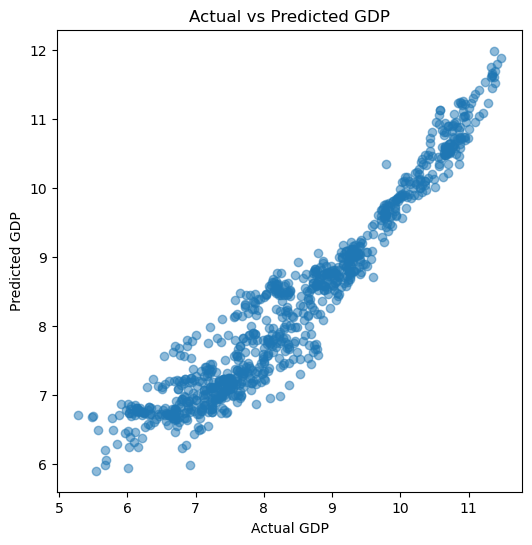

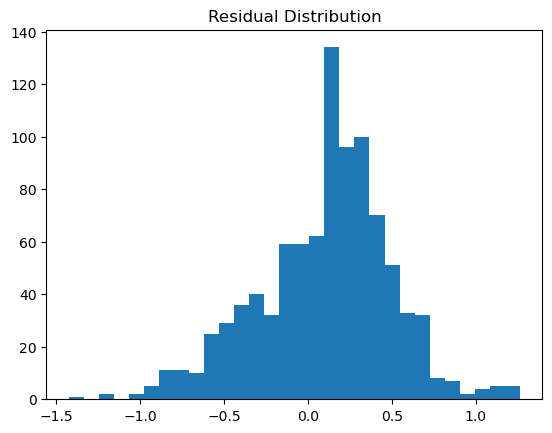

GDP_MA_3 1.882991671731636
Internet_Usage_% GDP_MA_3 -1.458679914322745
Internet_lag_1 GDP_MA_3 1.1925592575666368
Internet_Usage_% Year -0.7147076696241849
Internet_Usage_%^2 -0.5529174211831308
GDP_MA_3 Internet_Growth_Rate 0.5101321792736516
Internet_Usage_% Internet_lag_1 -0.4705761109531369
Internet_lag_1 0.32972006656237546
Internet_Smoothed Year 0.2792903848767732
Internet_MA_3 Year 0.2792903848765916


In [33]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

df = pd.read_csv("Cleaned_TimeSeries_Data_Enhanced.csv")
df.shape

df = df.sort_values(["Country Name", "Year"]).reset_index(drop=True)

df["Country_encoded"] = df["Country Name"].astype("category").cat.codes
df["Internet_Growth_Rate"] = df["Internet_Growth_Rate"].clip(-200, 200)

df.head()

df.isnull().sum()

y = np.log(df["GDP_per_Capita_USD"])

features = [
    "Internet_Usage_%",
    "Internet_Smoothed",
    "Internet_lag_1",
    "Internet_MA_3",
    "GDP_MA_3",
    "Internet_Growth_Rate",
    "Year",
    "Country_encoded"
]
X = df[features]

X = X.fillna(method="ffill").fillna(method="bfill")
y = y.fillna(method="ffill").fillna(method="bfill")

split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test_poly  = y.iloc[split_index:]

model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("ridge", Ridge(alpha=1.0))
])

model.fit(X_train, y_train)

pred_poly = model.predict(X_test)
print(pred_poly[:5])

import matplotlib.pyplot as plt
residuals = y_test_poly - pred_poly
plt.figure(figsize=(6,6))
plt.scatter(y_test_poly, pred_poly, alpha=0.5)
plt.xlabel("Actual GDP")
plt.ylabel("Predicted GDP")
plt.title("Actual vs Predicted GDP")
plt.show()
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.show()

feature_names = model.named_steps["poly"].get_feature_names_out(X.columns)
coefs = model.named_steps["ridge"].coef_

importance = sorted(zip(feature_names, coefs), key=lambda x: abs(x[1]), reverse=True)

for f, c in importance[:10]:
    print(f, c)


In [34]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

results = []

def evaluate(name, y_true, y_pred):
    results.append({
        "Model": name,
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    })

# Model 1
pred1 = model1.predict(X1_test)
evaluate("Baseline Linear", y1_test, pred1)

# Model 2
pred2 = model2.predict(X2_test)
evaluate("Smoothed Linear", y2_test, pred2)

# Model 3
pred3 = model3.predict(X3_test)
evaluate("Lag Linear", y3_test, pred3)

# Model 4 (FIXED)
evaluate("Lasso", y_test_lasso, pred_lasso)

# Model 5 (FIXED)
evaluate("Polynomial Ridge", y_test_poly, pred_poly)
print("Train R2 poly:", model.score(X_train,y_train))

results_df = pd.DataFrame(results)

print(results_df.sort_values("R2", ascending=False))

Train R2 poly: 0.9272007929543539
              Model        R2          MAE          RMSE
4  Polynomial Ridge  0.916965     0.331020      0.408203
3             Lasso  0.827970     0.450733      0.595323
2        Lag Linear  0.775574     0.536735      0.671094
1   Smoothed Linear  0.489154  8588.503105  12209.963810
0   Baseline Linear  0.458886  9149.640404  12881.582085


In [35]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test_poly, pred_poly)
mae = mean_absolute_error(y_test_poly, pred_poly)
mse = mean_squared_error(y_test_poly, pred_poly)
rmse = np.sqrt(mse)

print("FINAL MODEL: Polynomial Ridge Regression")
print("R2 Score :", r2)
print("MAE      :", mae)
print("MSE      :", mse)
print("RMSE     :", rmse)

FINAL MODEL: Polynomial Ridge Regression
R2 Score : 0.916965227825254
MAE      : 0.3310204817866564
MSE      : 0.16663009462052328
RMSE     : 0.40820349658047184


## Model Comparison Conclusion

Among all trained models (Baseline Linear Regression, Smoothed Linear Regression, Internet Lag Model, Lasso Regression, and Polynomial Ridge Regression), the **Polynomial Ridge Regression model performed the best**.

It achieved:

* **R² Score:** 0.9169
* **MAE:** 0.3310
* **MSE:** 0.1666
* **RMSE:** 0.4082

These results indicate **strong predictive performance**, meaning the model successfully captured the relationship between **internet penetration and GDP per capita**.

Polynomial features helped capture **non-linear relationships**, while Ridge regularization reduced overfitting and improved generalization.

Therefore, **Polynomial Ridge Regression was selected as the final model for GDP per capita prediction based on internet usage trends.**


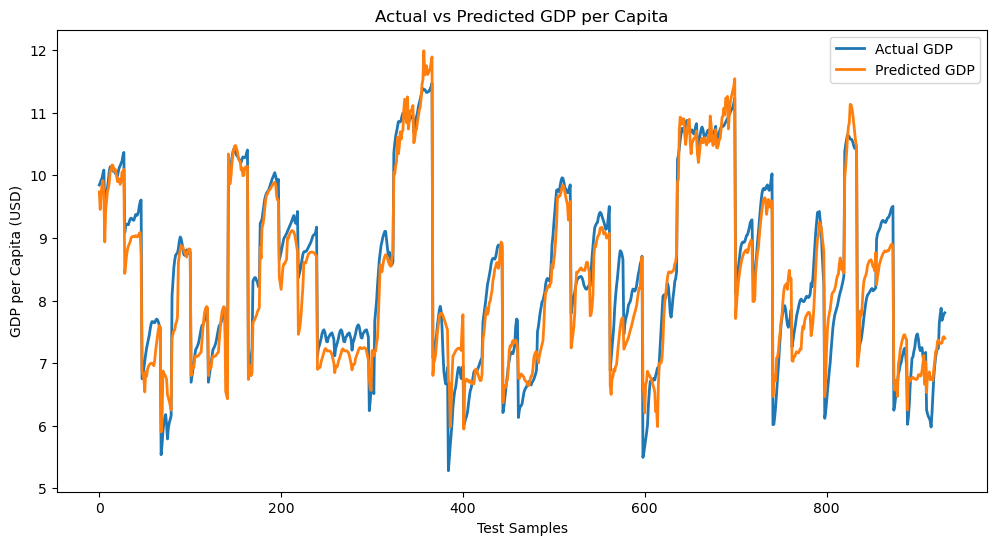

In [36]:
plt.figure(figsize=(12,6))

plt.plot(y_test_poly.values, label="Actual GDP", linewidth=2)
plt.plot(pred_poly, label="Predicted GDP", linewidth=2)

plt.title("Actual vs Predicted GDP per Capita")
plt.xlabel("Test Samples")
plt.ylabel("GDP per Capita (USD)")

plt.legend()
plt.show()

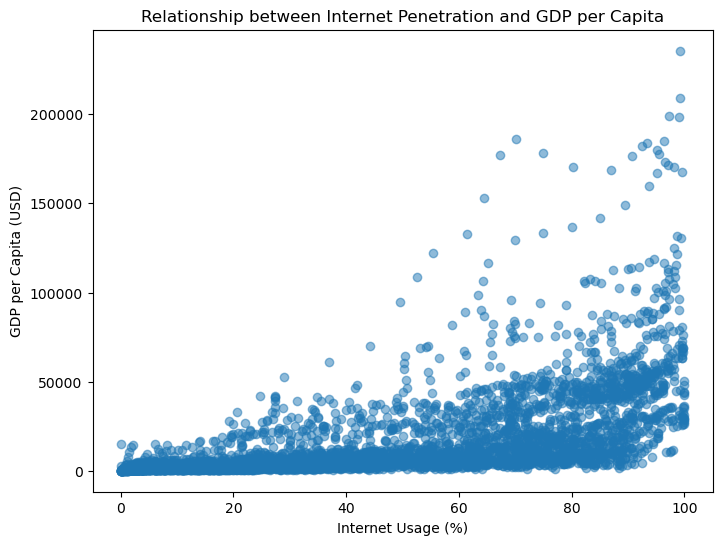

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(df["Internet_Usage_%"], df["GDP_per_Capita_USD"], alpha=0.5)

plt.title("Relationship between Internet Penetration and GDP per Capita")
plt.xlabel("Internet Usage (%)")
plt.ylabel("GDP per Capita (USD)")

plt.show()

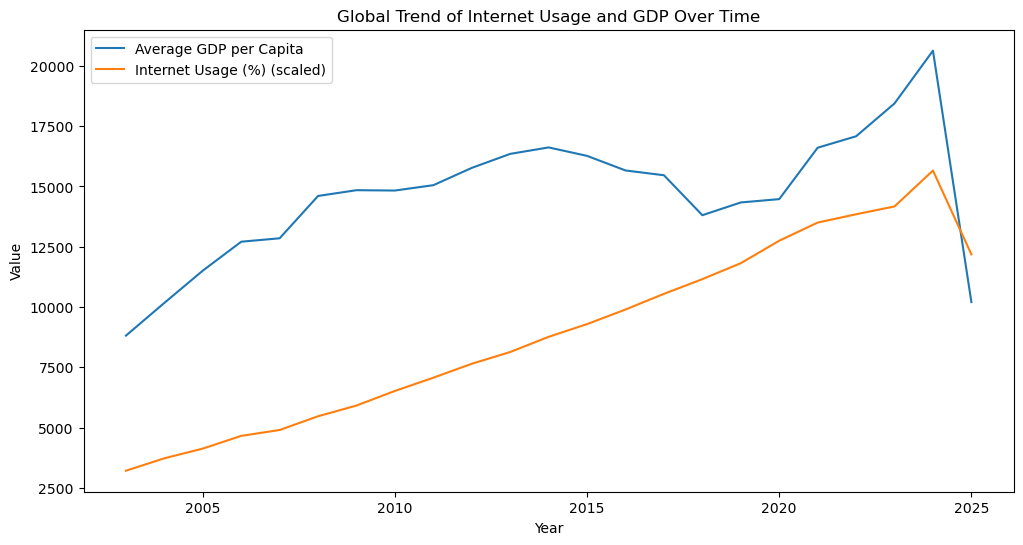

In [38]:
plt.figure(figsize=(12,6))

plt.plot(df.groupby("Year")["GDP_per_Capita_USD"].mean(),
         label="Average GDP per Capita")

plt.plot(df.groupby("Year")["Internet_Usage_%"].mean()*200,  # scaled for visibility
         label="Internet Usage (%) (scaled)")

plt.title("Global Trend of Internet Usage and GDP Over Time")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()

plt.show()

In [39]:
correlation = df["Internet_Usage_%"].corr(df["GDP_per_Capita_USD"])

print("Correlation between Internet Usage and GDP:", correlation)

Correlation between Internet Usage and GDP: 0.6035283437711297


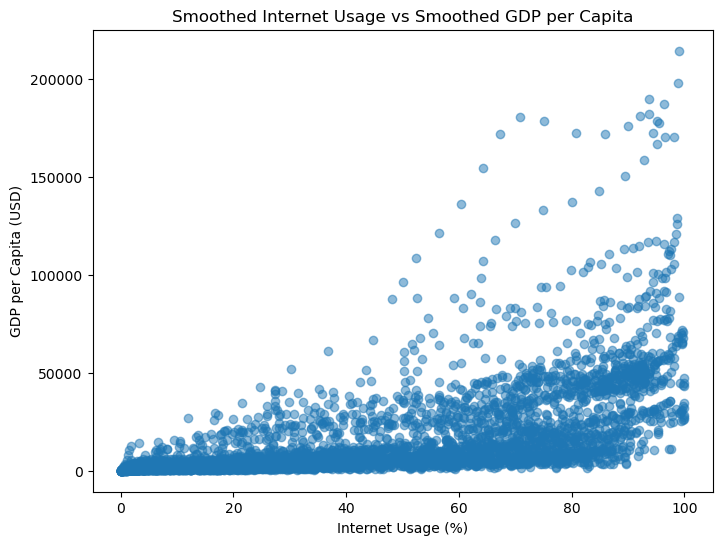

In [40]:
plt.figure(figsize=(8,6))

plt.scatter(df["Internet_MA_3"], df["GDP_MA_3"], alpha=0.5)

plt.title("Smoothed Internet Usage vs Smoothed GDP per Capita")
plt.xlabel("Internet Usage (%)")
plt.ylabel("GDP per Capita (USD)")

plt.show()

## Analysis Summary

The analysis shows a **strong positive relationship between internet penetration and GDP per capita**. Countries with higher internet usage generally tend to have higher economic output, highlighting the importance of digital connectivity in economic development.

After training multiple models, the **Polynomial Ridge Regression model achieved the best performance with an R² score of 0.9169**, demonstrating that internet penetration and its derived features are strong predictors of GDP per capita.

This confirms that increasing internet access is closely associated with economic growth, and machine learning models can effectively capture this relationship for prediction and analysis.
